In [1]:
# Seasonal Agriculture Performance Analysis
# VOIS AICTE Batch 1 2026-2027
# Major Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the agricultural dataset

df = pd.read_csv("seasonal_agriculture_performance_dataset (2).csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Number of rows: 4000
Number of columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [3]:
# Basic information about the dataset

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (4000, 28)

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                    

In [4]:
# Statistical summary of numerical columns

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


In [5]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3    

In [6]:
# Check duplicate records

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
# Step 6: Data Cleaning
# Filling missing numerical values with the median

numeric_columns = [
    'Rainfall_mm',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha'
]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after cleaning:")
print(df[numeric_columns].isnull().sum())

Missing values after cleaning:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


In [8]:
# Verify the cleaned dataset

print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())
print("Final dataset shape:", df.shape)

Total missing values: 0
Total duplicate rows: 0
Final dataset shape: (4000, 28)


In [9]:
# Step 7: Season-wise Agricultural Performance

season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Efficiency_t_per_1000m3
Season,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,5.89
Rabi,5.04,41.49,601526.05,513836.58,87689.47,5.19
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,4.41


In [10]:
# Number of records in each season

season_counts = df['Season'].value_counts()

print("Number of records by season:")
print(season_counts)

Number of records by season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


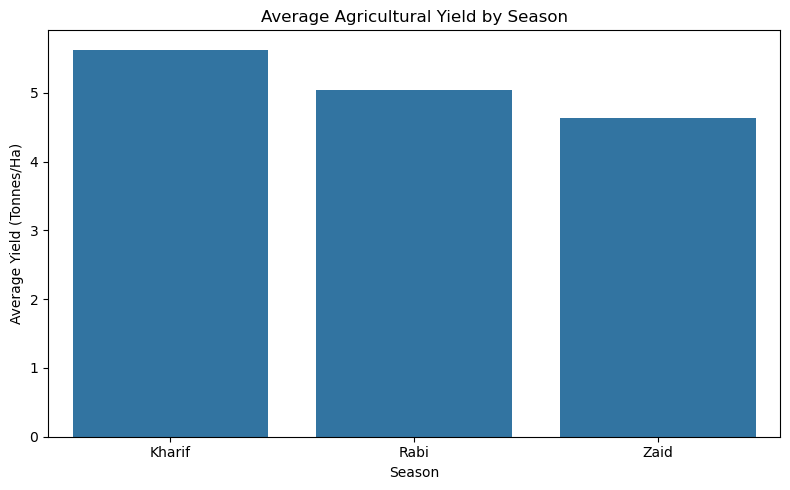

In [11]:
# Step 8: Average Yield by Season

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_summary.index,
    y=season_summary['Yield_Tonnes_Ha']
)

plt.title('Average Agricultural Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

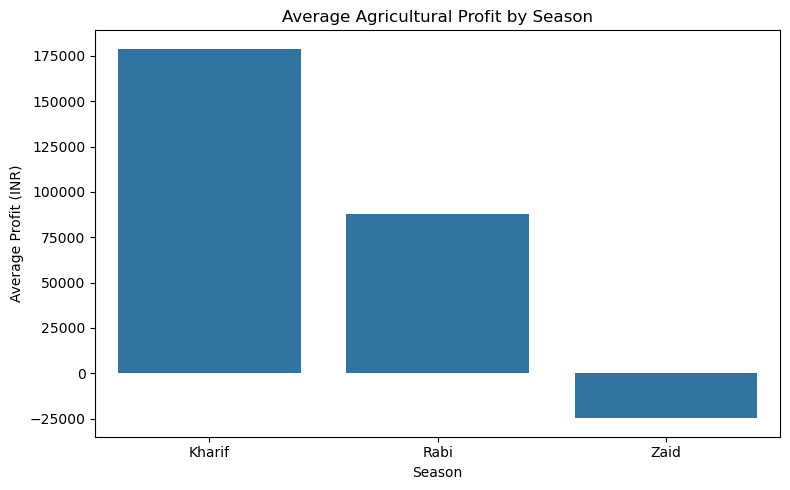

In [12]:
# Step 9: Average Profit by Season

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_summary.index,
    y=season_summary['Profit_INR']
)

plt.title('Average Agricultural Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.tight_layout()
plt.show()

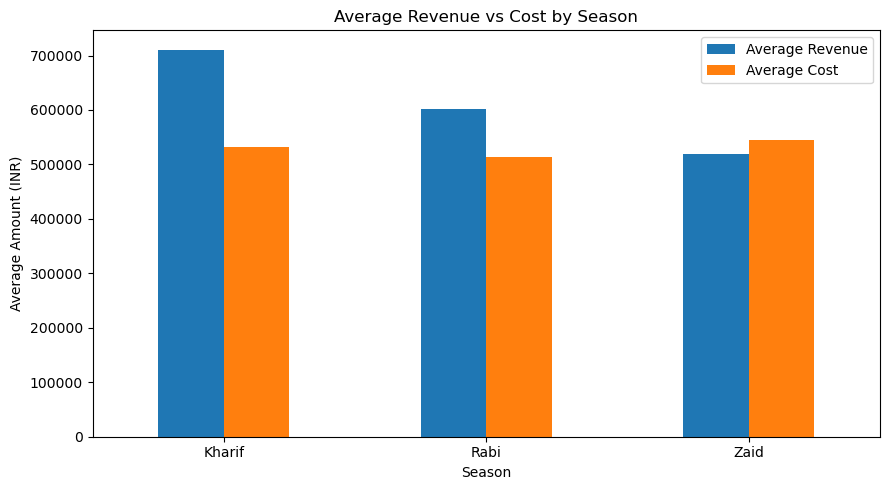

In [13]:
# Step 10: Average Revenue vs Cost by Season

revenue_cost = df.groupby('Season')[[
    'Revenue_INR',
    'Total_Cost_INR'
]].mean()

revenue_cost.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Average Revenue vs Cost by Season')
plt.xlabel('Season')
plt.ylabel('Average Amount (INR)')
plt.xticks(rotation=0)
plt.legend(['Average Revenue', 'Average Cost'])
plt.tight_layout()
plt.show()

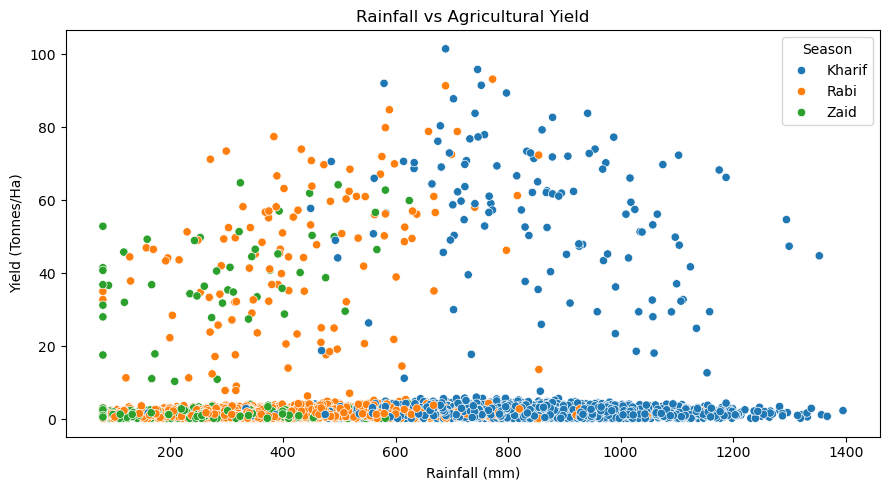

In [14]:
# Step 11: Relationship between Rainfall and Yield

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Agricultural Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

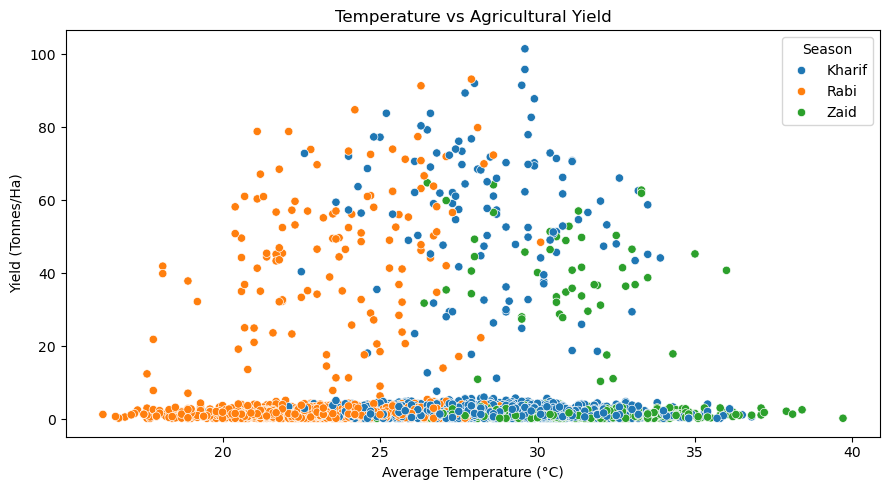

In [15]:
# Step 12: Relationship between Temperature and Yield

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Temperature vs Agricultural Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

In [16]:
# Step 13: Correlation Analysis

correlation_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Total_Cost_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

correlation_matrix = df[correlation_columns].corr()

# Correlation of variables with Yield
yield_correlation = correlation_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False)

print("Correlation with Yield:")
print(yield_correlation)

Correlation with Yield:
Yield_Tonnes_Ha                  1.00
Water_Efficiency_t_per_1000m3    0.91
Production_Tonnes                0.88
Profit_INR                       0.49
Revenue_INR                      0.43
Water_Used_m3                    0.39
Nitrogen_kg_ha                   0.05
Phosphorus_kg_ha                 0.05
Rainfall_mm                      0.03
Total_Cost_INR                   0.03
Disease_Pest_Risk_pct            0.01
Humidity_pct                     0.01
Soil_Moisture_pct                0.01
Avg_Temperature_C                0.01
Potassium_kg_ha                  0.00
Fertilizer_kg_ha                 0.00
Seed_Quality_Score              -0.01
Pesticide_Litre_ha              -0.01
Sunlight_Hours_Day              -0.02
Soil_pH                         -0.02
Name: Yield_Tonnes_Ha, dtype: float64


In [17]:
# Step 14: Crop-wise Agricultural Performance

crop_summary = df.groupby('Crop').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

crop_summary.sort_values(
    'Yield_Tonnes_Ha',
    ascending=False
)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Crop,,,,
Sugarcane,46.64,392.41,1371980.11,817187.99
Maize,2.71,21.78,457067.99,-83978.33
Rice,2.43,19.29,423615.26,-102213.50
Wheat,2.11,16.85,400104.89,-123398.34
Chilli,1.54,12.38,1276777.23,750878.34
Groundnut,1.32,9.66,542935.50,44858.12
Cotton,1.23,9.40,639423.08,124546.92
Pulses,0.92,7.40,528465.87,-4238.05


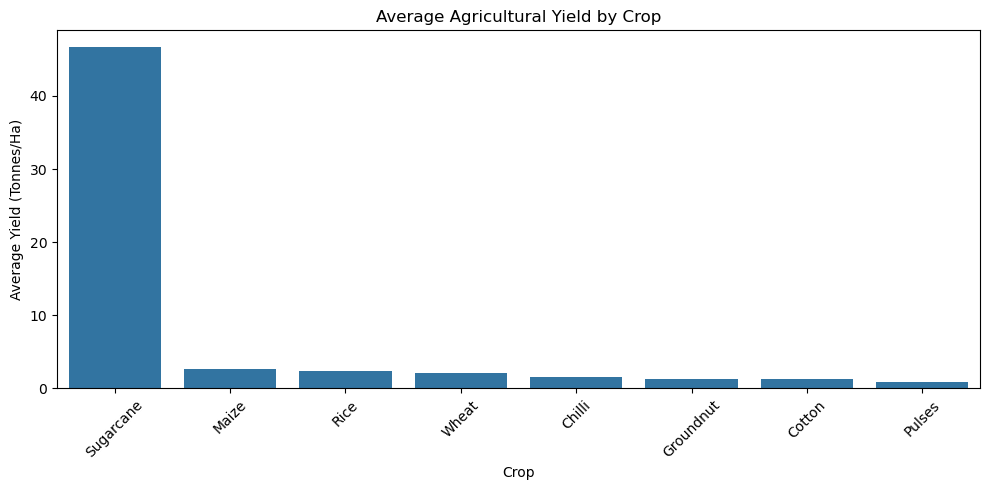

In [18]:
# Step 15: Average Yield by Crop

plt.figure(figsize=(10, 5))

crop_yield = crop_summary['Yield_Tonnes_Ha'].sort_values(ascending=False)

sns.barplot(
    x=crop_yield.index,
    y=crop_yield.values
)

plt.title('Average Agricultural Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Step 16: Season-wise Crop Yield Analysis

season_crop_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
).round(2)

season_crop_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


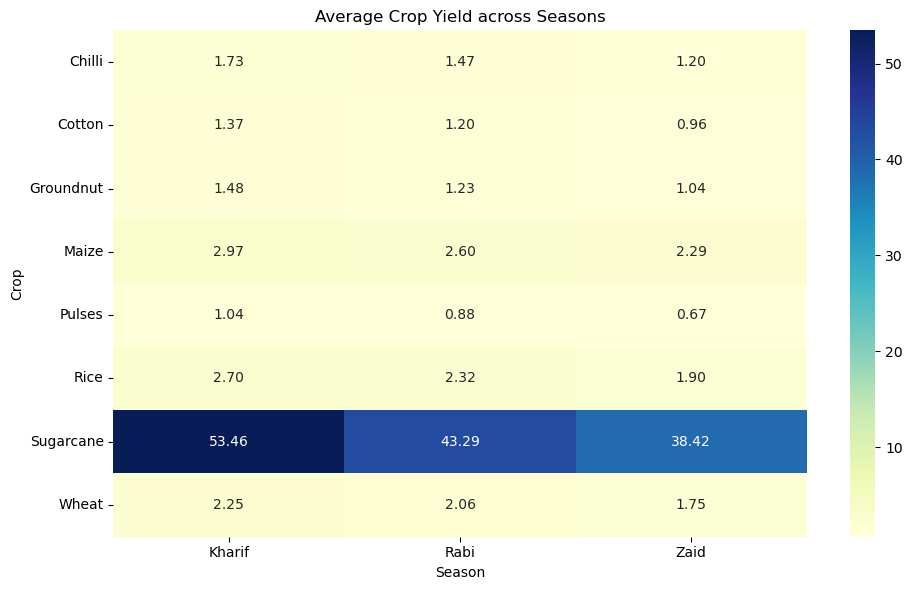

In [20]:
# Heatmap: Crop Yield across Seasons

plt.figure(figsize=(10, 6))

sns.heatmap(
    season_crop_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Crop Yield across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

In [21]:
# Step 17: Water Efficiency by Season

water_summary = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().round(2)

print("Average Water Efficiency by Season:")
print(water_summary)

Average Water Efficiency by Season:
Season
Kharif   5.89
Rabi     5.19
Zaid     4.41
Name: Water_Efficiency_t_per_1000m3, dtype: float64


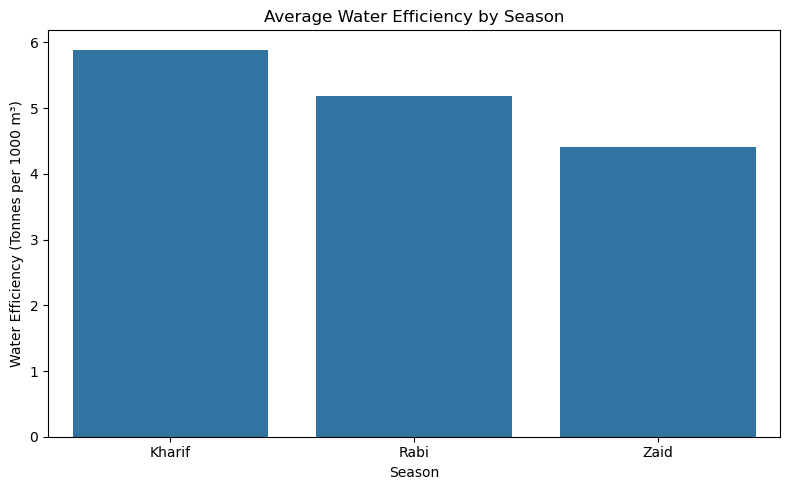

In [22]:
# Visualization: Water Efficiency by Season

plt.figure(figsize=(8, 5))

sns.barplot(
    x=water_summary.index,
    y=water_summary.values
)

plt.title('Average Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.tight_layout()
plt.show()

In [24]:
# Step 18: Key Findings

# Calculate best-performing seasons again
best_y = season_summary['Yield_Tonnes_Ha'].idxmax()
best_p = season_summary['Profit_INR'].idxmax()

print("KEY FINDINGS")
print("=" * 60)

print(f"1. {best_y} has the highest average yield.")
print(f"2. {best_p} has the highest average profit.")
print("3. Kharif has the highest average water efficiency.")
print("4. Zaid has negative average profit because its average cost is higher than its average revenue.")
print("5. Water efficiency has the strongest correlation with yield (0.91).")
print("6. Production has a strong positive correlation with yield (0.88).")
print("7. Rainfall (0.03) and temperature (0.01) show very weak linear correlation with yield.")
print("8. Sugarcane has the highest average yield among the crops.")
print("9. Seasonal and crop-wise analysis shows noticeable variation in agricultural performance.")

KEY FINDINGS
1. Kharif has the highest average yield.
2. Kharif has the highest average profit.
3. Kharif has the highest average water efficiency.
4. Zaid has negative average profit because its average cost is higher than its average revenue.
5. Water efficiency has the strongest correlation with yield (0.91).
6. Production has a strong positive correlation with yield (0.88).
7. Rainfall (0.03) and temperature (0.01) show very weak linear correlation with yield.
8. Sugarcane has the highest average yield among the crops.
9. Seasonal and crop-wise analysis shows noticeable variation in agricultural performance.


In [25]:
# Step 19: Conclusion

print("""
CONCLUSION
==========

The analysis shows clear differences in agricultural performance across
seasons and crops.

Kharif performs best in terms of average yield, profit and water efficiency,
while Zaid shows comparatively weaker economic performance.

Water efficiency has a strong positive association with yield in this dataset.
Crop-wise analysis also shows substantial differences, with Sugarcane recording
the highest average yield.

These findings can support better seasonal planning, resource management and
further investigation of agricultural productivity.
""")


CONCLUSION

The analysis shows clear differences in agricultural performance across
seasons and crops.

Kharif performs best in terms of average yield, profit and water efficiency,
while Zaid shows comparatively weaker economic performance.

Water efficiency has a strong positive association with yield in this dataset.
Crop-wise analysis also shows substantial differences, with Sugarcane recording
the highest average yield.

These findings can support better seasonal planning, resource management and
further investigation of agricultural productivity.



In [26]:
# Step 20: Recommendations

print("""
RECOMMENDATIONS
===============

1. Improve water-use efficiency to support higher agricultural productivity.
2. Consider seasonal performance while planning crop activities.
3. Investigate the causes of negative profitability during Zaid season.
4. Use crop-wise performance information for better crop planning.
5. Monitor environmental and resource-related factors along with yield.
6. Use predictive analytics and machine learning for future seasonal planning.
""")


RECOMMENDATIONS

1. Improve water-use efficiency to support higher agricultural productivity.
2. Consider seasonal performance while planning crop activities.
3. Investigate the causes of negative profitability during Zaid season.
4. Use crop-wise performance information for better crop planning.
5. Monitor environmental and resource-related factors along with yield.
6. Use predictive analytics and machine learning for future seasonal planning.

